# Preprocesamiento segun Bolanos y Rufiner

In [8]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [6]:
# cargo los datos del sujeto 1
data = np.load('../data/preprocesamiento_segun_bolanos_rufiner/S01_preprocessed.npz')
print(data.files)
print(data['x'].shape)
print(data['y'].shape)

['x', 'y']
(688, 36)
(688, 3)


In [7]:
x_vocal = data['x'][data['y'][:,1] <= 5]
y_vocal = data['y'][data['y'][:,1] <= 5]
x_comando = data['x'][data['y'][:,1] >= 6]
y_comando = data['y'][data['y'][:,1] >= 6]

In [12]:
n_components = 2
perplexity = 10
max_iter = 2000
semilla = 17

# Ejecutar t-SNE para Vocales
tsne_v = TSNE(n_components=n_components, perplexity=perplexity, 
             random_state=semilla, max_iter=max_iter)
v_embedded = tsne_v.fit_transform(x_vocal)
# Ejecutar t-SNE para Comandos
tsne_c = TSNE(n_components=n_components, perplexity=perplexity, 
             random_state=semilla, max_iter=max_iter)
c_embedded = tsne_c.fit_transform(x_comando)

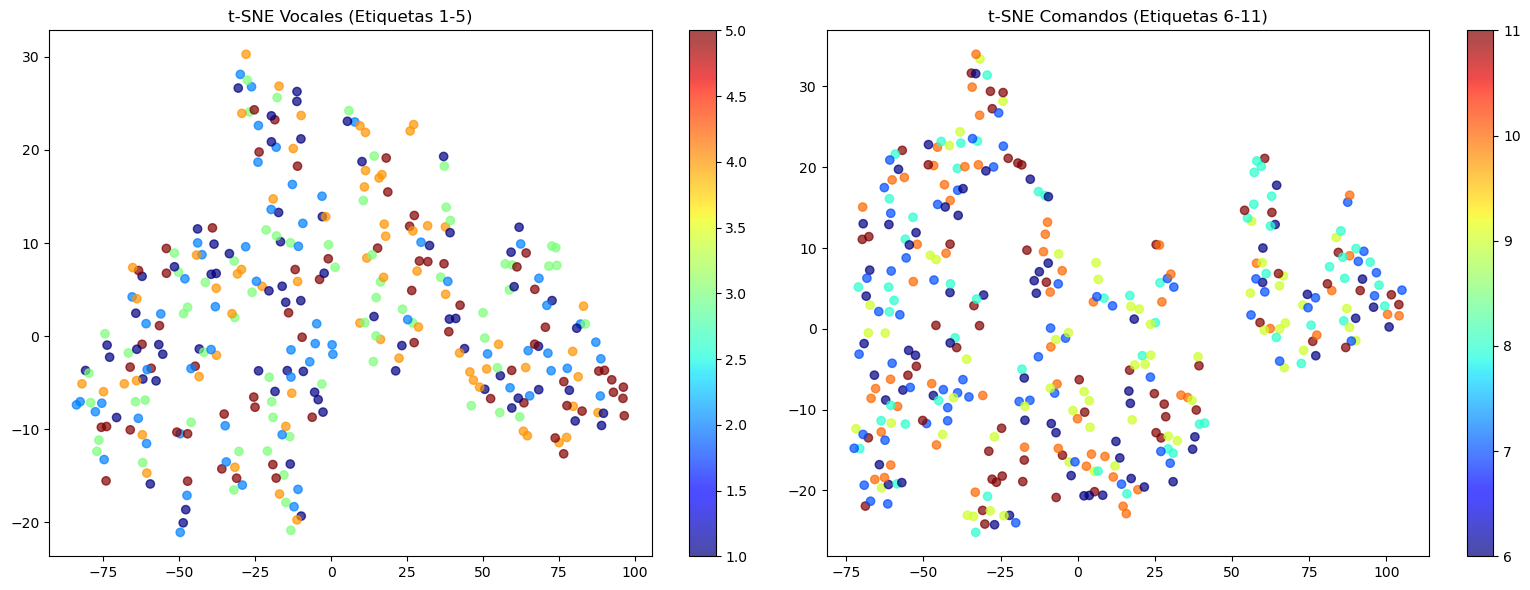

In [13]:
# Graficar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# Scatter Vocales
scatter1 = ax1.scatter(v_embedded[:, 0], v_embedded[:, 1], c=y_vocal[:, 1], cmap='jet', alpha=0.7)
ax1.set_title('t-SNE Vocales (Etiquetas 1-5)')
plt.colorbar(scatter1, ax=ax1)
# Scatter Comandos
scatter2 = ax2.scatter(c_embedded[:, 0], c_embedded[:, 1], c=y_comando[:, 1], cmap='jet', alpha=0.7)
ax2.set_title('t-SNE Comandos (Etiquetas 6-11)')
plt.colorbar(scatter2, ax=ax2)
plt.tight_layout()
plt.show()